# LeetCode #510: Inorder Successor in BST II

https://leetcode.com/problems/inorder-successor-in-bst-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (in-order collect)** | $O(n)$ | $O(n)$ |
| **Optimal: Parent Pointer Traversal ★** | $O(h)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (in-order collect)
Traverse the entire BST in-order to build a sorted list of nodes, then find the given node and return the next one. Requires $O(n)$ time and $O(n)$ space even when the answer is just one step away.

### Optimal: Parent Pointer Traversal ★
Two cases: (1) if the node has a right child, the successor is the leftmost node of the right subtree; (2) otherwise, walk up via parent pointers until arriving from a left child — that ancestor is the successor. Both cases run in $O(h)$ time with $O(1)$ extra space by exploiting the parent pointers provided by the node definition.

**Why this is better than Brute Force:** Parent pointers allow finding the successor without traversing the whole tree — just a short walk up or down from the target node.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 10^4]$
* $-10^5 \le \text{Node.val} \le 10^5$
* All `Node.val` are unique


## Solutions

### C#

In [ ]:
public Node InorderSuccessor(Node node) {
    // Case 1: successor is leftmost node of right subtree
    if (node.right != null) {
        Node curr = node.right;
        while (curr.left != null) curr = curr.left;
        return curr;
    }
    // Case 2: walk up until we arrive from a left child
    Node n = node;
    while (n.parent != null && n == n.parent.right) n = n.parent;
    return n.parent;
}

### Python

In [ ]:
def inorder_successor(node):
    # Case 1: successor is leftmost node of right subtree
    if node.right:
        curr = node.right
        while curr.left:
            curr = curr.left
        return curr
    # Case 2: walk up until we arrive from a left child
    n = node
    while n.parent and n == n.parent.right:
        n = n.parent
    return n.parent

### Go

In [ ]:
func inorderSuccessor(node *Node) *Node {
    // Case 1: successor is leftmost node of right subtree
    if node.Right != nil {
        curr := node.Right
        for curr.Left != nil { curr = curr.Left }
        return curr
    }
    // Case 2: walk up until we arrive from a left child
    n := node
    for n.Parent != nil && n == n.Parent.Right {
        n = n.Parent
    }
    return n.Parent
}

### Rust

In [ ]:
// Node uses raw pointers for parent links in Rust's ownership model
pub fn inorder_successor(node: *mut Node) -> *mut Node {
    unsafe {
        if !(*node).right.is_null() {
            // Case 1: successor is leftmost node of right subtree
            let mut curr = (*node).right;
            while !(*curr).left.is_null() { curr = (*curr).left; }
            return curr;
        }
        // Case 2: walk up until we arrive from a left child
        let mut n = node;
        while !(*n).parent.is_null() && n == (*(*n).parent).right {
            n = (*n).parent;
        }
        (*n).parent
    }
}

## Example Scenarios

**1. Common Case**
**Input:** BST `[2,1,3]`, node = 1
Node 1 has no right child. Walk up: 1 is a left child of 2 → stop. Successor = 2. One parent hop.

**2. Slightly Complex**
**Input:** BST `[5,3,6,2,4,null,null,1]`, node = 3
Node 3 has a right child (4). Leftmost of right subtree = 4 (no left child). Successor = 4. One right step.

**3. Edge Case: Time Factor**
**Input:** Right-skewed BST `[1,null,2,null,...,null,n]`, node = `n`
Node $n$ is a leaf with no right child. Walk all the way up through $n$ parent pointers (each node was a right child) to reach null. Successor = null (no successor exists). $O(h) = O(n)$ hops.

**4. Edge Case: Space Factor**
**Input:** Any BST, node with a right subtree of depth $h$
Case 1 descends the right subtree leftward — at most $h$ steps — with no extra allocation. $O(1)$ space regardless of subtree size.

**5. Almost-Impossible but Plausible**
**Input:** BST where node = root and root has no right child
Case 2: root has no parent → `n.parent == null` → loop exits immediately. Return `n.parent = null`. Correctly indicates there is no in-order successor for the maximum element.


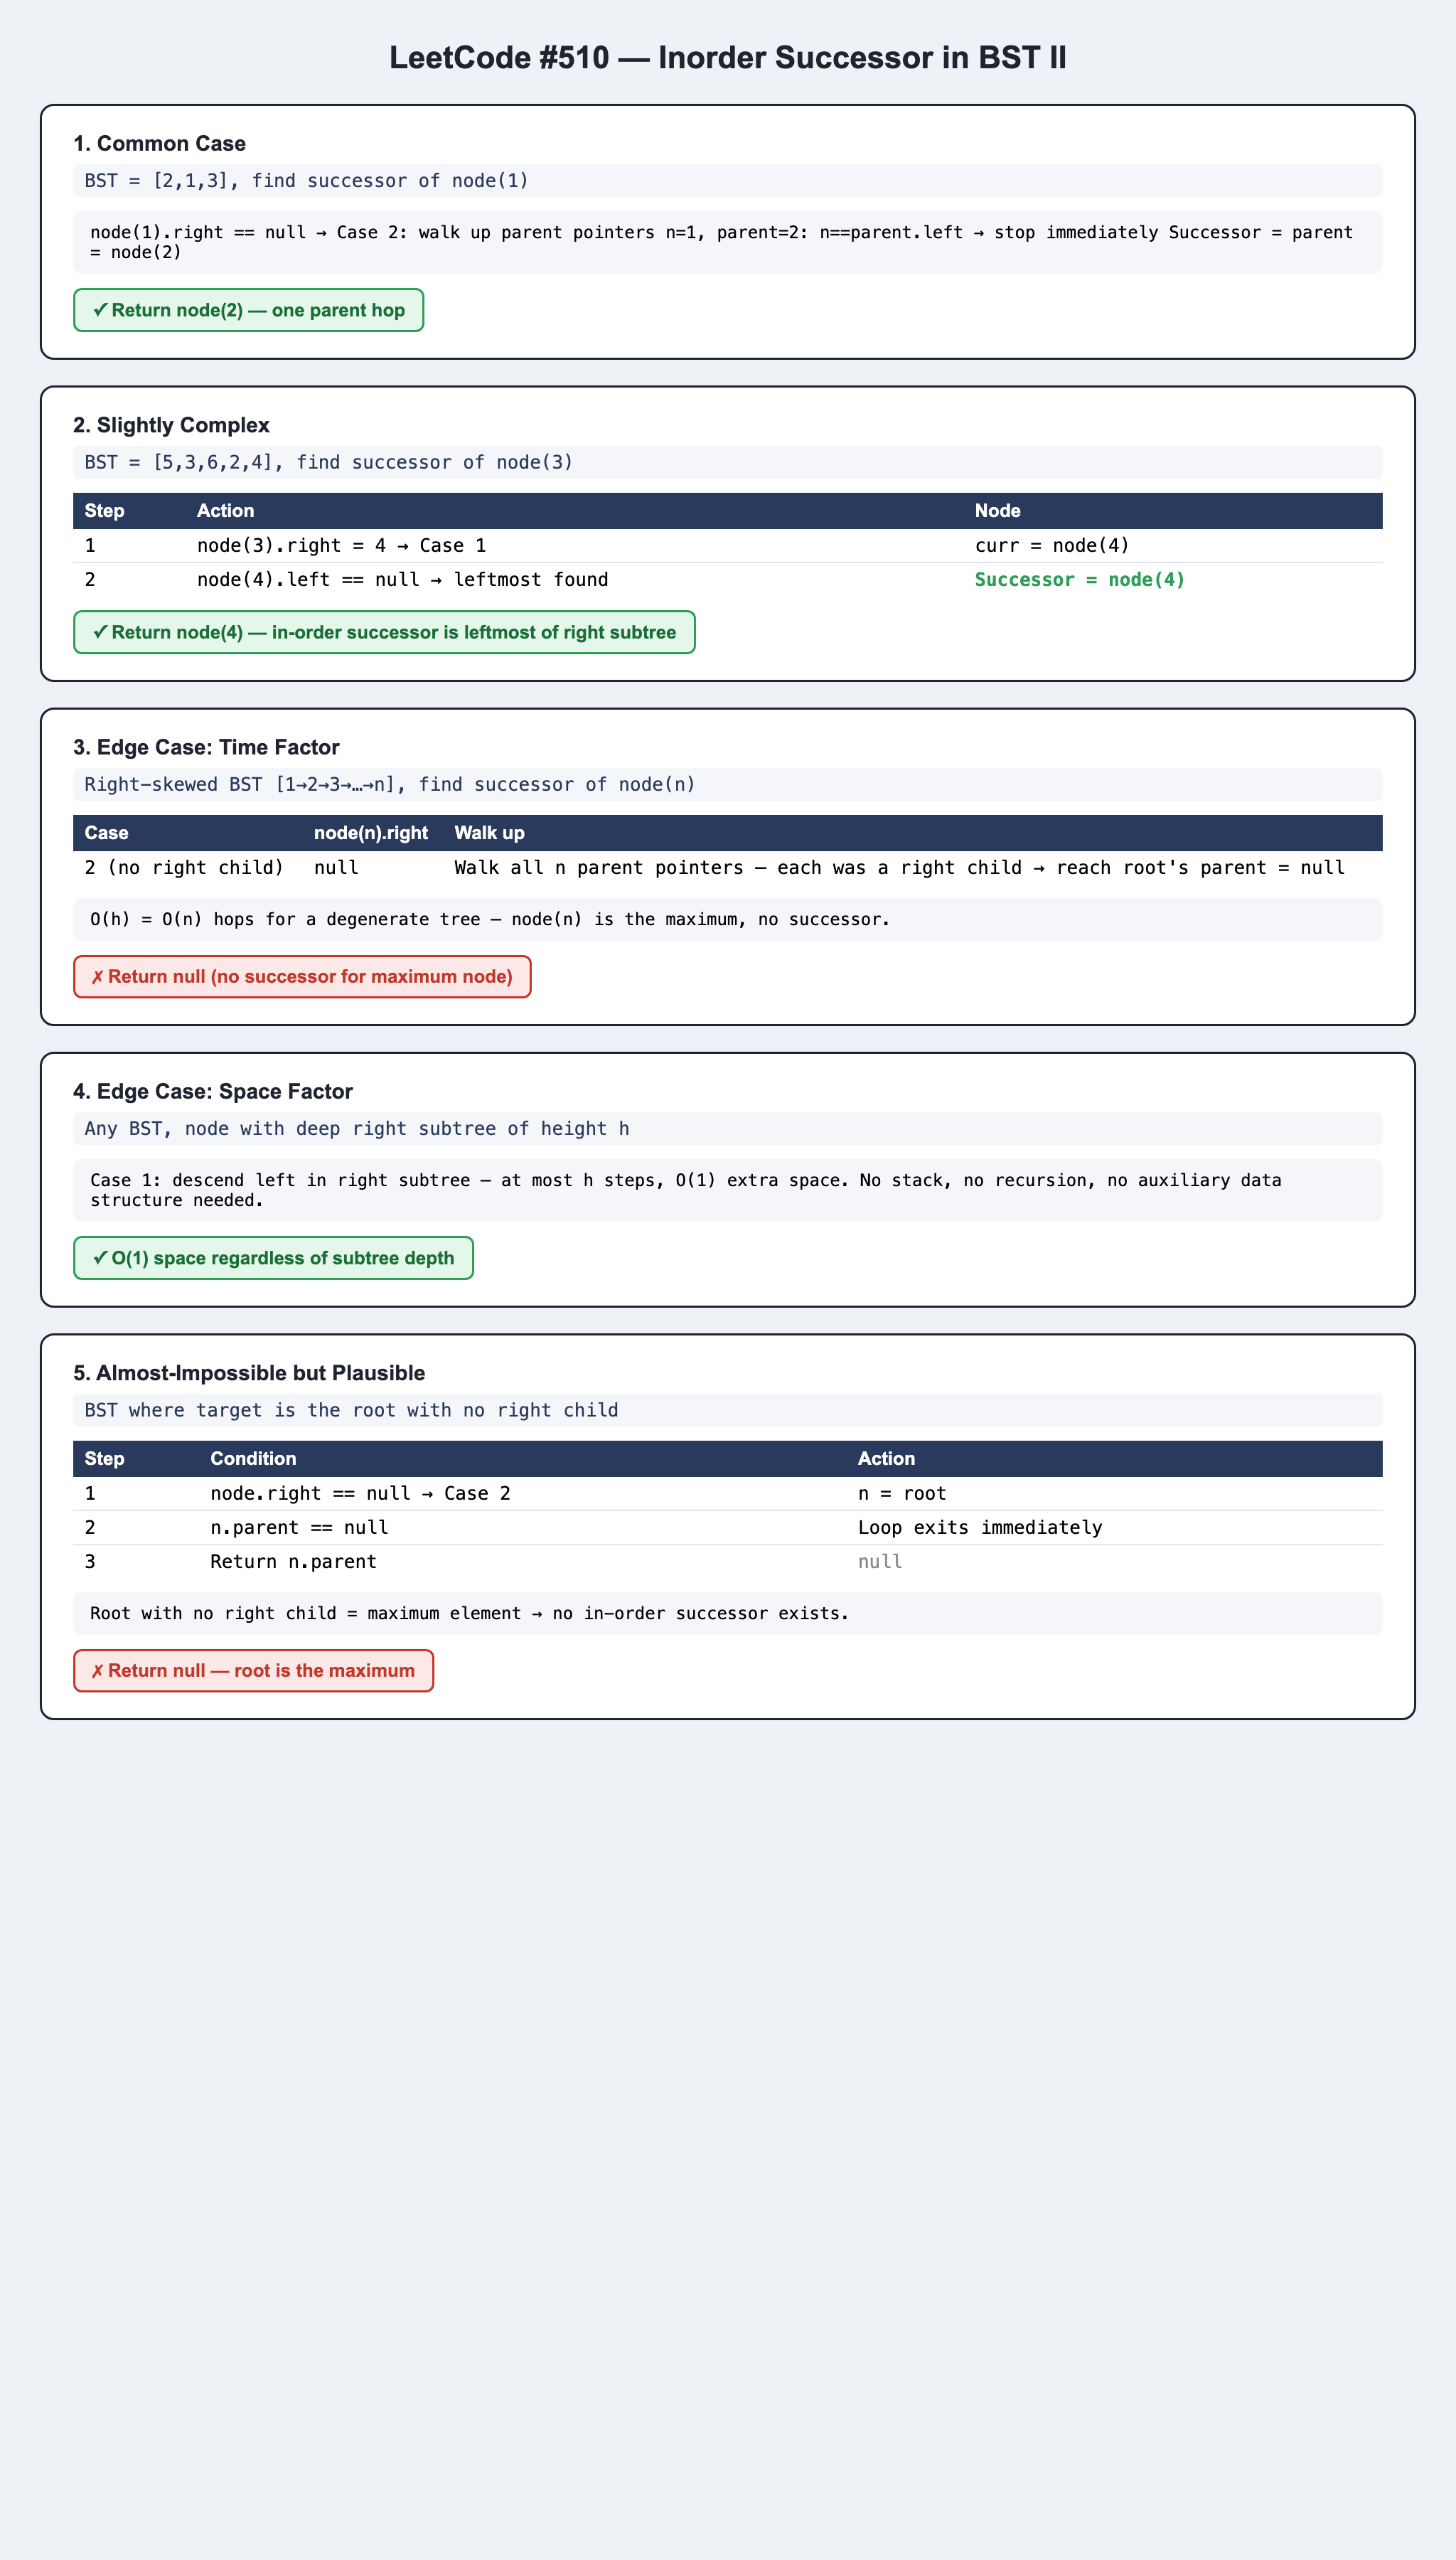